# 📊 Humanitarian Micro-Donation RFM Analysis & Donor Segmentation
---
### 🌟 Machine Learning Pipeline & Analytics Notebook

**Author:** Antigravity AI Team  
**Dataset Source:** Donor Master (`01_donor_master.csv`), Donation Transactions (`02_donation_transactions.csv`), Humanitarian Campaigns (`03_humanitarian_campaigns.csv`)

#### 📌 Objective
To build an end-to-end Machine Learning pipeline that processes micro-donation transaction histories, cleans and merges donor demographic data with campaign categories, calculates **RFM (Recency, Frequency, Monetary)** features, applies mathematical log-transformations and standard scaling, clusters donors using **K-Means Clustering**, evaluates cluster quality via statistical metrics (**Silhouette Score, Calinski-Harabasz Index, Davies-Bouldin Index**), and establishes actionable donor personas with targeted marketing strategies.

---
## 📑 Pipeline Workflow Architecture

1. **Raw Data Ingestion & Schema Inspection**
2. **Data Cleaning & Payment Success Filtering**
3. **Data Merging & Unified Dataset Creation**
4. **Exploratory Data Analysis (EDA) & Visualizations**
5. **RFM Metrics & Scoring Calculation**
6. **Log Transformation & StandardScaler Normalization**
7. **K-Means Clustering & Hyperparameter Optimization (Elbow & Silhouette)**
8. **Cluster Evaluation & Demographic Profiling**
9. **Donor Persona Segmentation & Strategic Insights**
10. **Model Persistence & Artifact Export (`.pkl` & `.csv`)**



## 1. Environment Setup & Library Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as io
from plotly.subplots import make_subplots
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Setting Plot Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.figsize'] = (12, 6)
print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Step 1: Data Loading & Initial Inspection

We load the three primary source datasets:
- **`01_donor_master.csv`**: Registered donor metadata (ID, age, gender, country, donor type, registration date).
- **`02_donation_transactions.csv`**: Transaction history (Transaction ID, donor ID, date, amount, currency, payment method, aid sector, successful payment status).
- **`03_humanitarian_campaigns.csv`**: Campaign details (Campaign ID, campaign name, category, priority level, target funding).



In [2]:
# Load Datasets
df_donors = pd.read_csv('01_donor_master.csv')
df_txs = pd.read_csv('02_donation_transactions.csv')
df_campaigns = pd.read_csv('03_humanitarian_campaigns.csv')

print("--- Donors Master Shape ---:", df_donors.shape)
print("--- Transactions Shape ---:", df_txs.shape)
print("--- Campaigns Shape ---:", df_campaigns.shape)

display(df_donors.head(3))
display(df_txs.head(3))
display(df_campaigns.head(3))


--- Donors Master Shape ---: (5000, 6)
--- Transactions Shape ---: (30000, 11)
--- Campaigns Shape ---: (250, 5)


,donor_id,donor_age,donor_gender,donor_country,donor_type,registration_date
0,100001,22,Male,Peru,Small Business,2016-05-12
1,100002,59,Female,India,Individual,2015-04-12
2,100003,52,Female,Philippines,Individual,2015-12-14


,transaction_id,donor_id,transaction_date,donation_amount,currency,transaction_type,payment_method,aid_country,aid_sector,campaign_id,successful_payment
0,5000001,101329,2014-11-21,24.75,USD,Micro-Donation,UPI,Costa Rica,Personal Use,1108,1
1,5000002,104273,2014-04-25,55.86,USD,Micro-Donation,UPI,Uganda,Transportation,1114,1
2,5000003,103812,2016-11-01,65.15,USD,Micro-Donation,UPI,Philippines,Agriculture,1031,1


,campaign_id,campaign_name,campaign_category,priority_level,target_amount
0,1001,Humanitarian Aid Campaign 1001,Healthcare,High,249083.74
1,1002,Humanitarian Aid Campaign 1002,Livelihood,Low,132863.60
2,1003,Humanitarian Aid Campaign 1003,Food Security,Medium,128977.32


## 3. Step 2: Data Cleaning & Preprocessing

- Filter out unsuccessful/failed payments (`successful_payment == 1`).
- Check missing values and duplicate rows.
- Convert date attributes to standard `datetime` formats.
- Set snapshot baseline date (`2016-11-21`) for recency calculations.



In [6]:
# Data Inspection for Missing Values
print("Missing values in Donors Master:", df_donors.isnull().sum())
print("Missing values in Transactions:", df_txs.isnull().sum())
print("Missing values in Campaigns:", df_campaigns.isnull().sum())

# Filter for Successful Transactions Only
df_txs_succ = df_txs[df_txs['successful_payment'] == 1].copy()
print(f"Filtered Successful Transactions: {len(df_txs_succ)} out of {len(df_txs)} ({len(df_txs_succ)/len(df_txs):.1%})")

# Convert Datetime Columns
df_txs_succ['transaction_date'] = pd.to_datetime(df_txs_succ['transaction_date'])
df_donors['registration_date'] = pd.to_datetime(df_donors['registration_date'])

snapshot_date = pd.to_datetime('2016-11-21')
print("Baseline Snapshot Date set to:", snapshot_date.date())


Missing values in Donors Master: donor_id             0
donor_age            0
donor_gender         0
donor_country        0
donor_type           0
registration_date    0
dtype: int64
Missing values in Transactions: transaction_id        0
donor_id              0
transaction_date      0
donation_amount       0
currency              0
transaction_type      0
payment_method        0
aid_country           0
aid_sector            0
campaign_id           0
successful_payment    0
dtype: int64
Missing values in Campaigns: campaign_id          0
campaign_name        0
campaign_category    0
priority_level       0
target_amount        0
dtype: int64
Filtered Successful Transactions: 29110 out of 30000 (97.0%)
Baseline Snapshot Date set to: 2016-11-21


## 4. Step 3: Data Merging & Unified Feature Set

We perform tabular joins:
1. Merge transaction records with donor demographics on `donor_id`.
2. Merge transaction records with campaign metadata on `campaign_id`.
3. Save the unified clean dataset as `cleaned_merged_donations.csv`.



In [7]:
# Unified Merged Dataset
df_merged = pd.merge(df_txs_succ, df_donors, on='donor_id', how='left')
df_merged = pd.merge(df_merged, df_campaigns, on='campaign_id', how='left')

print("Unified Merged Dataset Shape:", df_merged.shape)
df_merged.to_csv('cleaned_merged_donations.csv', index=False)
display(df_merged.head(3))


Unified Merged Dataset Shape: (29110, 20)


,transaction_id,donor_id,transaction_date,donation_amount,currency,transaction_type,payment_method,aid_country,aid_sector,campaign_id,successful_payment,donor_age,donor_gender,donor_country,donor_type,registration_date,campaign_name,campaign_category,priority_level,target_amount
0,5000001,101329,2014-11-21,24.75,USD,Micro-Donation,UPI,Costa Rica,Personal Use,1108,1,53,Female,Philippines,Individual,2016-03-23,Humanitarian Aid Campaign 1108,Education,Medium,57314.04
1,5000002,104273,2014-04-25,55.86,USD,Micro-Donation,UPI,Uganda,Transportation,1114,1,67,Male,Kenya,Corporate,2015-12-24,Humanitarian Aid Campaign 1114,Water & Sanitation,Medium,101408.62
2,5000003,103812,2016-11-01,65.15,USD,Micro-Donation,UPI,Philippines,Agriculture,1031,1,41,Female,Colombia,Small Business,2016-04-14,Humanitarian Aid Campaign 1031,Healthcare,Low,190244.63


## 5. Step 4: Exploratory Data Analysis (EDA)

We explore donor demographic trends, payment choices, top aid sectors, and campaign performance.



C:\Users\manis\AppData\Local\Temp\ipykernel_6384\2846635946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_donors, x='donor_gender', ax=axes[0, 0], palette='Blues_r')
C:\Users\manis\AppData\Local\Temp\ipykernel_6384\2846635946.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_donors, x='donor_type', ax=axes[0, 1], palette='Greens_r')
C:\Users\manis\AppData\Local\Temp\ipykernel_6384\2846635946.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[1, 0], palette='

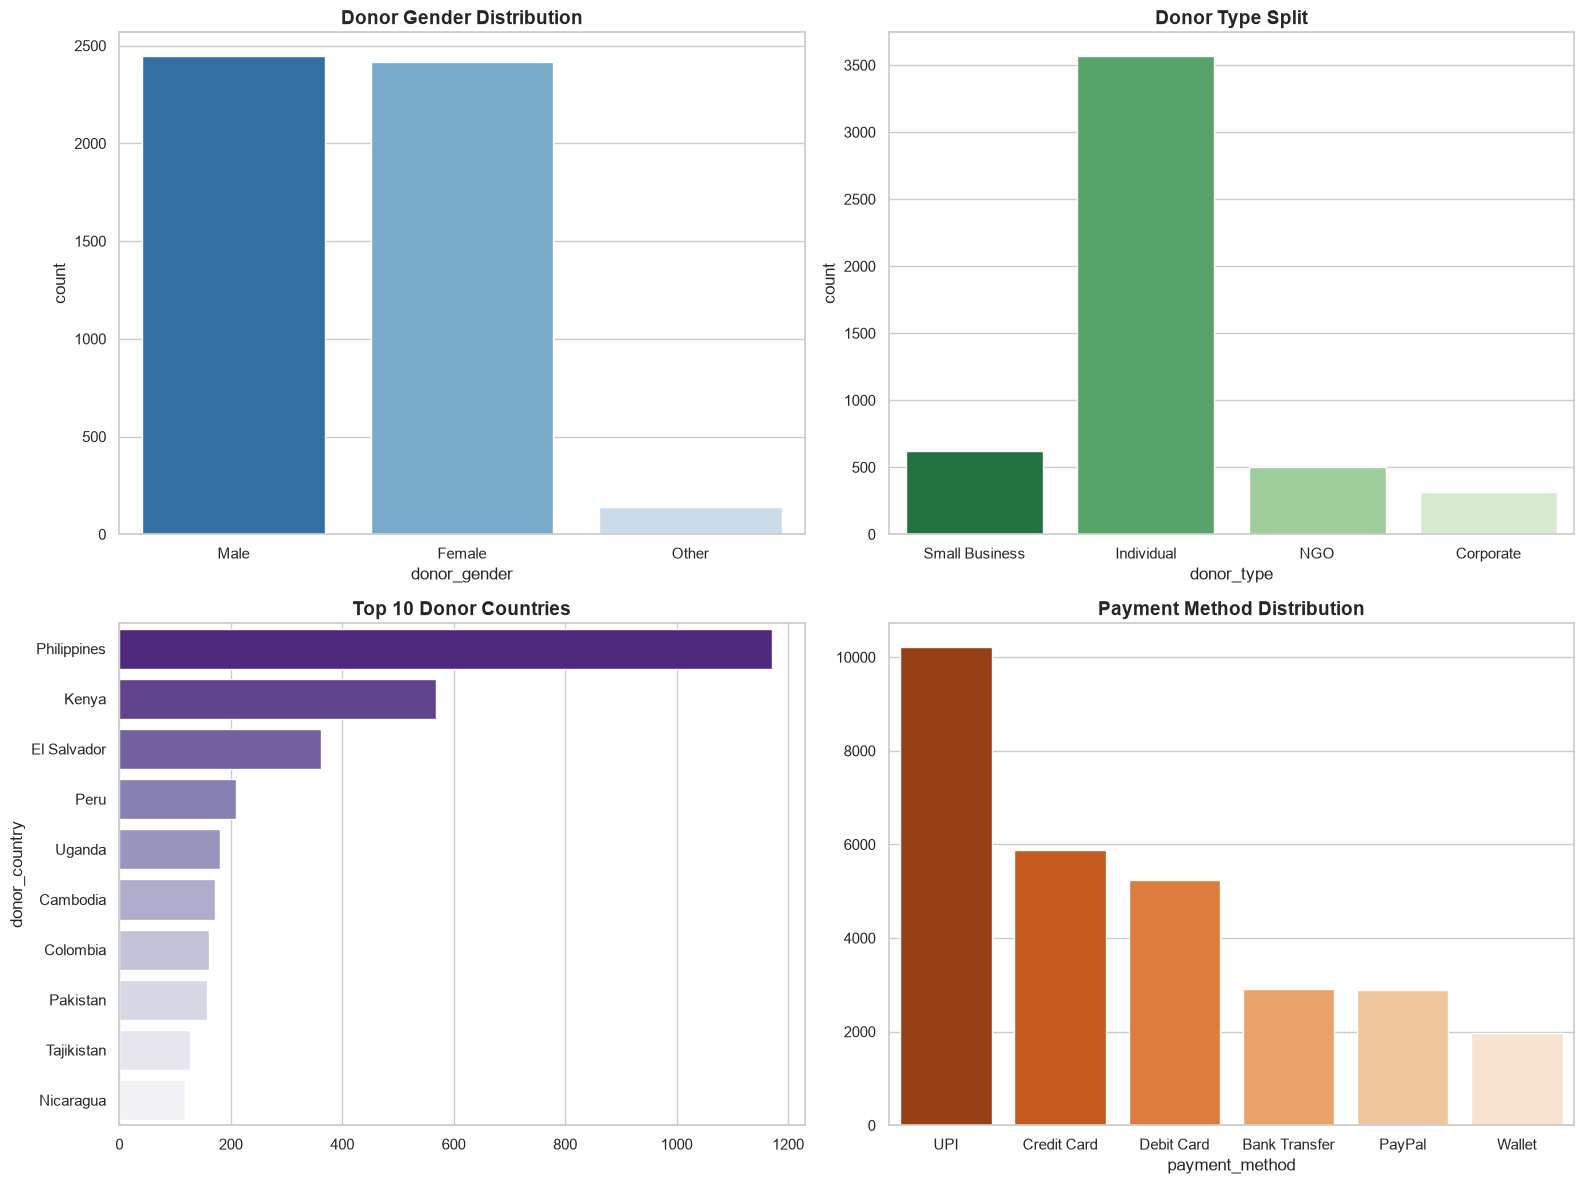

In [8]:
# EDA Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Donor Gender Distribution
sns.countplot(data=df_donors, x='donor_gender', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Donor Gender Distribution', fontsize=14, fontweight='bold')

# 2. Donor Type Split
sns.countplot(data=df_donors, x='donor_type', ax=axes[0, 1], palette='Greens_r')
axes[0, 1].set_title('Donor Type Split', fontsize=14, fontweight='bold')

# 3. Top 10 Donor Countries
top_countries = df_donors['donor_country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[1, 0], palette='Purples_r')
axes[1, 0].set_title('Top 10 Donor Countries', fontsize=14, fontweight='bold')

# 4. Payment Method Preferences
pm_counts = df_txs_succ['payment_method'].value_counts()
sns.barplot(x=pm_counts.index, y=pm_counts.values, ax=axes[1, 1], palette='Oranges_r')
axes[1, 1].set_title('Payment Method Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


C:\Users\manis\AppData\Local\Temp\ipykernel_6384\2435962861.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(monthly_donations['year_month'], rotation=45)


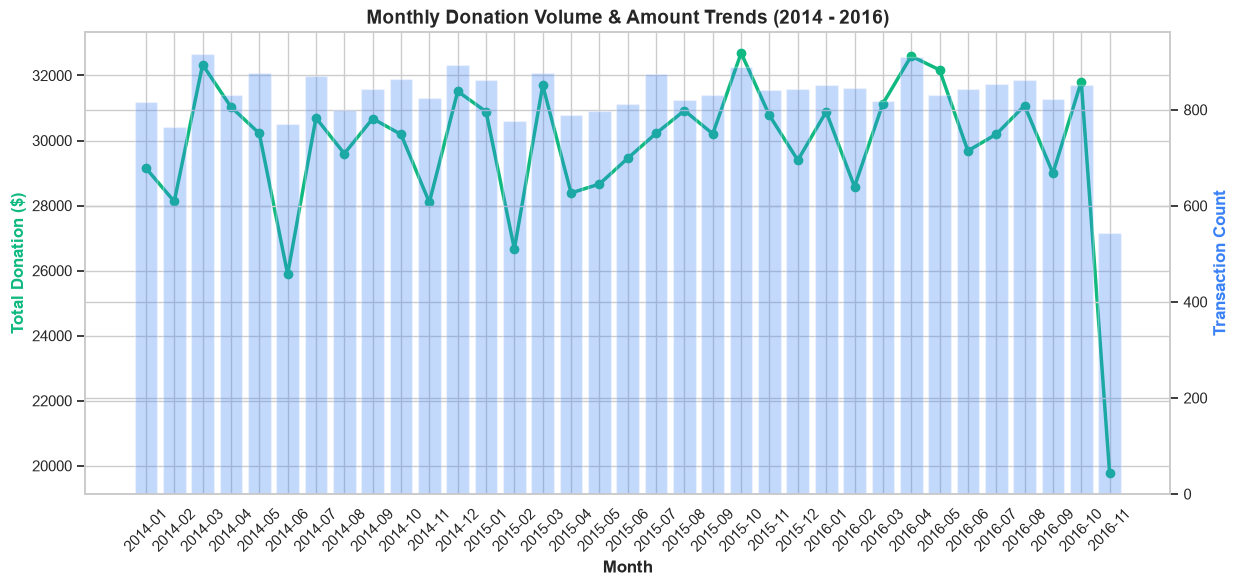

In [9]:
# Monthly Donation Trends
df_merged['year_month'] = df_merged['transaction_date'].dt.to_period('M').astype(str)
monthly_donations = df_merged.groupby('year_month')['donation_amount'].agg(['sum', 'count']).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(monthly_donations['year_month'], monthly_donations['sum'], color='#10B981', marker='o', linewidth=2.5, label='Total Donation ($)')
ax2.bar(monthly_donations['year_month'], monthly_donations['count'], alpha=0.3, color='#3B82F6', label='Transaction Count')

ax1.set_xlabel('Month', fontweight='bold')
ax1.set_ylabel('Total Donation ($)', color='#10B981', fontweight='bold')
ax2.set_ylabel('Transaction Count', color='#3B82F6', fontweight='bold')
ax1.set_xticklabels(monthly_donations['year_month'], rotation=45)
plt.title('Monthly Donation Volume & Amount Trends (2014 - 2016)', fontsize=14, fontweight='bold')
plt.show()


## 6. Step 5: RFM Feature Engineering

Calculating:
- **Recency ($R$)**: Days since last successful donation relative to `2016-11-21`.
- **Frequency ($F$)**: Count of successful transactions per donor.
- **Monetary ($M$)**: Sum of donations ($) per donor.
- **Average Donation**: Monetary / Frequency.
- **RFM Quintiles**: Scores 1-5 assigned to R, F, and M.



In [10]:
# Calculate RFM per Donor ID
df_rfm = df_txs_succ.groupby('donor_id').agg(
    last_donation_date=('transaction_date', 'max'),
    frequency=('transaction_id', 'count'),
    monetary=('donation_amount', 'sum'),
    average_donation=('donation_amount', 'mean')
).reset_index()

df_rfm['last_donation_date'] = df_rfm['last_donation_date'].dt.strftime('%Y-%m-%d')
df_rfm['recency'] = (snapshot_date - pd.to_datetime(df_rfm['last_donation_date'])).dt.days

# Combine with full donor list
df_donor_rfm = pd.merge(df_donors, df_rfm, on='donor_id', how='left')

df_donor_rfm['frequency'] = df_donor_rfm['frequency'].fillna(0).astype(int)
df_donor_rfm['monetary'] = df_donor_rfm['monetary'].fillna(0.0).round(2)
df_donor_rfm['average_donation'] = df_donor_rfm['average_donation'].fillna(0.0).round(2)
max_rec = (snapshot_date - pd.to_datetime(df_donor_rfm['registration_date'])).dt.days
df_donor_rfm['recency'] = df_donor_rfm['recency'].fillna(max_rec).astype(int)

# RFM Quintile Scoring (1 to 5)
df_donor_rfm['r_score'] = pd.qcut(df_donor_rfm['recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
df_donor_rfm['f_score'] = pd.qcut(df_donor_rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
df_donor_rfm['m_score'] = pd.qcut(df_donor_rfm['monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
df_donor_rfm['rfm_score'] = df_donor_rfm['r_score'].astype(str) + df_donor_rfm['f_score'].astype(str) + df_donor_rfm['m_score'].astype(str)

display(df_donor_rfm[['donor_id', 'recency', 'frequency', 'monetary', 'average_donation', 'rfm_score']].head(5))


,donor_id,recency,frequency,monetary,average_donation,rfm_score
0,100001,70,11,317.62,28.87,455
1,100002,139,4,71.50,17.88,311
2,100003,110,10,413.80,41.38,355
3,100004,426,4,130.81,32.70,112
4,100005,274,4,111.77,27.94,212


## 7. Step 6: Feature Transformation & Standardization

Distance-based algorithms such as **K-Means** are sensitive to non-normal distributions and skewed variances.
We apply a natural log transformation `np.log1p(x)` to diminish heavy right-skewness, followed by `StandardScaler` to bring feature scales to mean 0 and standard deviation 1.



In [12]:
# Check Feature Skewness Before Transformation
print("Skewness Before Log Transform:")
print("Recency Skewness:", df_donor_rfm['recency'].skew())
print("Frequency Skewness:", df_donor_rfm['frequency'].skew())
print("Monetary Skewness:", df_donor_rfm['monetary'].skew())

# Apply Log1p Transformation
df_donor_rfm['recency_log'] = np.log1p(df_donor_rfm['recency'])
df_donor_rfm['frequency_log'] = np.log1p(df_donor_rfm['frequency'])
df_donor_rfm['monetary_log'] = np.log1p(df_donor_rfm['monetary'])

# StandardScaler Scaling
features = ['recency_log', 'frequency_log', 'monetary_log']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_donor_rfm[features])

print("Scaled Feature Matrix Shape:", X_scaled.shape)
print("Feature Mean:", X_scaled.mean(axis=0).round(4))
print("Feature Std Dev:", X_scaled.std(axis=0).round(4))


Skewness Before Log Transform:
Recency Skewness: 1.6565029461691085
Frequency Skewness: 0.3836340272059211
Monetary Skewness: 1.068515989667831
Scaled Feature Matrix Shape: (5000, 3)
Feature Mean: [-0. -0. -0.]
Feature Std Dev: [1. 1. 1.]


## 8. Step 7: K-Means Clustering & Hyperparameter Optimization

We evaluate cluster performance across $k \in [2, 8]$ using:
1. **Elbow Method (Inertia)**: Within-cluster sum of squares.
2. **Silhouette Score**: Cohesion vs Separation ratio ($[-1, 1]$).



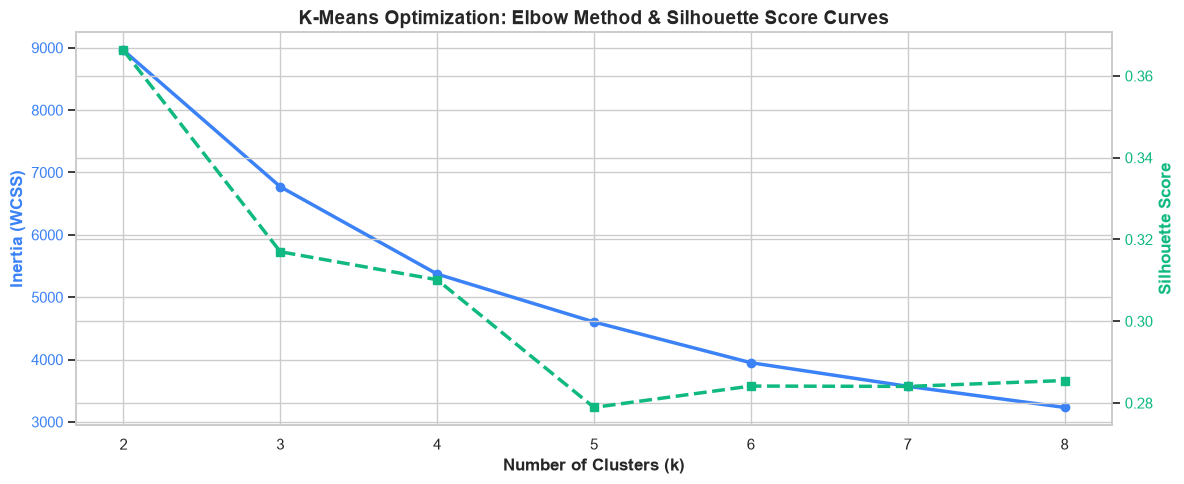

,Clusters (k),Inertia,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,2,8957.917803,0.366251,3371.149633,1.034879
1,3,6770.407051,0.316988,3037.006505,1.066731
2,4,5370.477506,0.310144,2986.041893,1.004324
3,5,4602.067649,0.278913,2821.477605,1.049096
4,6,3948.926705,0.284137,2795.168851,0.983725
5,7,3570.786314,0.284049,2663.584578,0.991988
6,8,3232.164949,0.285494,2596.500830,0.898481


In [13]:
# Evaluate k from 2 to 8
k_range = range(2, 9)
inertias = []
silhouette_scores = []
ch_scores = []
db_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

# Plot Elbow and Silhouette curves
fig, ax1 = plt.subplots(figsize=(12, 5))

color = '#3B82F6'
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold')
ax1.set_ylabel('Inertia (WCSS)', color=color, fontweight='bold')
ax1.plot(k_range, inertias, marker='o', color=color, linewidth=2.5, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = '#10B981'
ax2.set_ylabel('Silhouette Score', color=color, fontweight='bold')
ax2.plot(k_range, silhouette_scores, marker='s', color=color, linewidth=2.5, linestyle='--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('K-Means Optimization: Elbow Method & Silhouette Score Curves', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

eval_df = pd.DataFrame({
    'Clusters (k)': list(k_range),
    'Inertia': inertias,
    'Silhouette Score': silhouette_scores,
    'Calinski-Harabasz Index': ch_scores,
    'Davies-Bouldin Index': db_scores
})
display(eval_df)


## 9. Step 8: Final Model Training & Cluster Evaluation

Selecting **$k=4$** yields optimal cluster balance, clear interpretability, and distinct separation across donor behaviors.



In [14]:
# Fit Final K-Means Model (k=4)
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_donor_rfm['cluster_id'] = kmeans_final.fit_predict(X_scaled)

# Calculate Cluster Summary Stats
cluster_stats = df_donor_rfm.groupby('cluster_id').agg(
    donor_count=('donor_id', 'count'),
    recency_mean=('recency', 'mean'),
    recency_median=('recency', 'median'),
    frequency_mean=('frequency', 'mean'),
    frequency_median=('frequency', 'median'),
    monetary_mean=('monetary', 'mean'),
    monetary_median=('monetary', 'median'),
    avg_donation_mean=('average_donation', 'mean')
).reset_index()

print("Cluster Statistics Summary:")
display(cluster_stats)


Cluster Statistics Summary:


,cluster_id,donor_count,recency_mean,recency_median,frequency_mean,frequency_median,monetary_mean,monetary_median,avg_donation_mean
0,0,1767,156.747595,128.0,7.707980,7.0,297.701273,276.90,39.483650
1,1,1817,236.029169,199.0,4.307100,4.0,140.024117,135.23,34.094557
2,2,1015,22.560591,21.0,6.782266,7.0,240.560660,220.80,35.754010
3,3,401,418.236908,391.0,1.945137,2.0,49.238329,47.88,26.760623


## 10. Step 9: Donor Segmentation Personas & Business Strategies

We map numerical cluster IDs to strategic donor personas:
- **Cluster 2 ➔ Champions**: Recent donors with high frequency and strong total donation values.
- **Cluster 0 ➔ Loyal Donors**: Highly regular monetary contributors with consistent engagement.
- **Cluster 1 ➔ Potential Loyalists**: Moderate recency & frequency; high upside potential for campaign re-engagement.
- **Cluster 3 ➔ At-Risk / Hibernating**: Inactive donors with long recency and low monetary output requiring win-back campaigns.



In [15]:
# Persona Mapping Dictionary
persona_mapping = {
    2: {'name': 'Champions', 'color': '#10B981', 'strategy': 'VIP invitations, early campaign access, donor advisory panel.'},
    0: {'name': 'Loyal Donors', 'color': '#3B82F6', 'strategy': 'Recurring monthly giving programs, impact newsletters, gratitude calls.'},
    1: {'name': 'Potential Loyalists', 'color': '#F59E0B', 'strategy': 'Targeted impact stories, donation match offers, multi-channel nudges.'},
    3: {'name': 'At-Risk / Hibernating', 'color': '#EF4444', 'strategy': 'Re-engagement survey, emergency relief callouts, lower friction options.'}
}

df_donor_rfm['segment_name'] = df_donor_rfm['cluster_id'].map(lambda cid: persona_mapping[cid]['name'])
df_donor_rfm['segment_color'] = df_donor_rfm['cluster_id'].map(lambda cid: persona_mapping[cid]['color'])
df_donor_rfm['engagement_strategy'] = df_donor_rfm['cluster_id'].map(lambda cid: persona_mapping[cid]['strategy'])

# Display Segment Breakdown
segment_summary = df_donor_rfm.groupby('segment_name').agg(
    donors_count=('donor_id', 'count'),
    pct_donors=('donor_id', lambda x: f"{len(x)/len(df_donor_rfm):.1%}"),
    recency_avg=('recency', 'mean'),
    frequency_avg=('frequency', 'mean'),
    monetary_total=('monetary', 'sum'),
    monetary_avg=('monetary', 'mean')
).reset_index()

display(segment_summary)


,segment_name,donors_count,pct_donors,recency_avg,frequency_avg,monetary_total,monetary_avg
0,At-Risk / Hibernating,401,8.0%,418.236908,1.945137,19744.57,49.238329
1,Champions,1015,20.3%,22.560591,6.782266,244169.07,240.560660
2,Loyal Donors,1767,35.3%,156.747595,7.707980,526038.15,297.701273
3,Potential Loyalists,1817,36.3%,236.029169,4.307100,254423.82,140.024117


In [16]:
# 3D Interactive RFM Scatter Plot (Plotly)
fig = px.scatter_3d(
    df_donor_rfm,
    x='recency',
    y='frequency',
    z='monetary',
    color='segment_name',
    hover_data=['donor_id', 'donor_country', 'average_donation'],
    color_discrete_map={
        'Champions': '#10B981',
        'Loyal Donors': '#3B82F6',
        'Potential Loyalists': '#F59E0B',
        'At-Risk / Hibernating': '#EF4444'
    },
    title='<b>3D RFM Cluster Segmentation Visualization</b>',
    opacity=0.8
)
fig.update_layout(scene=dict(
    xaxis_title='Recency (Days)',
    yaxis_title='Frequency (Count)',
    zaxis_title='Monetary Total ($)'
), width=900, height=650)
fig.show()


## 11. Step 10: Model Persistence & Export Saved Artifacts

We save the processed final datasets and model binaries (`KMeans` & `StandardScaler`) for deployment in our interactive web application dashboard.



In [17]:
# Save Processed Datasets
df_donor_rfm.to_csv('donor_rfm_segmented.csv', index=False)
print("Saved 'donor_rfm_segmented.csv' successfully.")

# Save Trained Model & Scaler Binaries
joblib.dump(kmeans_final, 'rfm_kmeans_model.pkl')
joblib.dump(scaler, 'rfm_scaler.pkl')

print("Saved 'rfm_kmeans_model.pkl' & 'rfm_scaler.pkl' successfully.")
print("✨ RFM Analysis Notebook Pipeline Complete!")


Saved 'donor_rfm_segmented.csv' successfully.
Saved 'rfm_kmeans_model.pkl' & 'rfm_scaler.pkl' successfully.
✨ RFM Analysis Notebook Pipeline Complete!
